### import libraries ###

In [32]:
import pandas as pd
import numpy as np

### Load the Dataset ###

In [33]:
data=pd.read_csv(r"StudentPerformanceFactors.csv")
data.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Handling missing values

In [34]:
data.isnull().sum()
data["Teacher_Quality"]=data["Teacher_Quality"].fillna(data["Teacher_Quality"].mode()[0])
data["Parental_Education_Level"]=data["Parental_Education_Level"].fillna(data["Parental_Education_Level"].mode()[0])
data["Distance_from_Home"]=data["Distance_from_Home"].fillna(data["Distance_from_Home"].mode()[0])
data.isnull().sum()
data.shape



(6607, 20)

### handling outliers 

In [39]:
data = data[data["Exam_Score"] <= 100]
data[data["Exam_Score"] > 100]


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score


### encoding string columns 

In [40]:
data.select_dtypes(include='object').columns

data=pd.get_dummies(data,drop_first=True,dtype=int)
data.columns=data.columns.str.strip().str.lower().str.replace(" ","_",regex=False)
# data=data.astype(int)
data.head()

# data.dtypes
# data.head()
# data.isnull().sum()

,hours_studied,attendance,sleep_hours,previous_scores,tutoring_sessions,physical_activity,exam_score,parental_involvement_low,parental_involvement_medium,access_to_resources_low,...,teacher_quality_medium,school_type_public,peer_influence_neutral,peer_influence_positive,learning_disabilities_yes,parental_education_level_high_school,parental_education_level_postgraduate,distance_from_home_moderate,distance_from_home_near,gender_male
0,23,84,7,73,0,3,67,1,0,0,...,1,1,0,1,0,1,0,0,1,1
1,19,64,8,59,2,4,61,1,0,0,...,1,1,0,0,0,0,0,1,0,0
2,24,98,7,91,2,4,74,0,1,0,...,1,1,1,0,0,0,1,0,1,1
3,29,89,8,98,1,4,71,1,0,0,...,1,1,0,0,0,1,0,1,0,1
4,19,92,6,65,3,4,70,0,1,0,...,0,1,1,0,0,0,0,0,1,0


In [42]:
data.to_csv("encoded_student_data.csv",index=False)

### Separate dependent and independent features 

In [43]:
X=data.drop(columns=["exam_score"])
X
y=data["exam_score"]
y

0       67
1       61
2       74
3       71
4       70
        ..
6602    68
6603    69
6604    68
6605    68
6606    64
Name: exam_score, Length: 6606, dtype: int64

### train test splits 

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,
                                               random_state=42)

### Train the Linear Regression model 

In [45]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predict model 

In [46]:
y_pred=model.predict(X_test)
y_pred

array([66.01458738, 65.44513872, 67.57892942, ..., 66.22567959,
       69.37651595, 72.00728703], shape=(1322,))

### check the model score

In [47]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import cross_val_score

scores=cross_val_score(model,X,y,cv=5,scoring='r2')
print("Cross val score :",scores)
print("Avg CV Score :",scores.mean())
print()

print("R2-Score :",r2_score(y_test,y_pred))
print("MAE Score :",mean_absolute_error(y_test,y_pred))
print("MSE Score :",mean_squared_error(y_test,y_pred))
print("RMSE Score :",np.sqrt(mean_squared_error(y_test,y_pred)))
print()

print("Train Score :",model.score(X_train,y_train))
print("Test Score :",model.score(X_test,y_test))



Cross val score : [0.62555872 0.74476619 0.70883637 0.73323805 0.83998031]
Avg CV Score : 0.730475927655045

R2-Score : 0.8249999018449949
MAE Score : 0.4159761177572428
MSE Score : 2.314239627149146
RMSE Score : 1.521262510926088

Train Score : 0.7109787258188146
Test Score : 0.8249999018449949


The linear regression model was evaluated using 5-fold cross-validation achieving an average R square score of 0.7261 indicating stable model performence across the different data splits

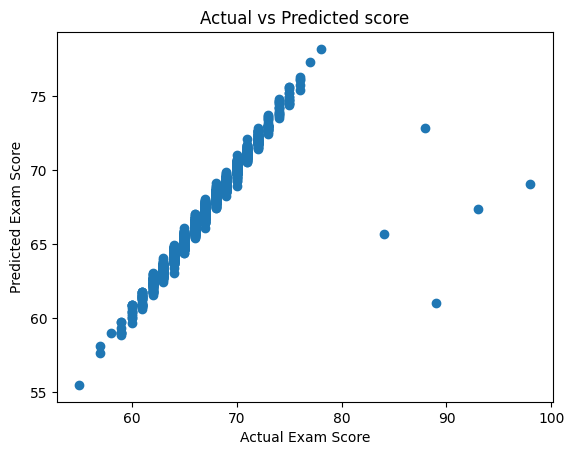

In [48]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted score")
plt.show()

### Test the Model by passing data values 

In [49]:
new_data=pd.DataFrame([[17,94,6,80,0,1,0,1,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1,1]])
model.predict(new_data)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([69.40196813])

#### Check R2 score and cross val score across different algorithms and choose best model.

#### DECISION TREE CLASSIFIER

In [50]:
#DECISION TREE CLASSIFIER

from sklearn.tree import DecisionTreeRegressor
DTR=DecisionTreeRegressor(max_depth=5,random_state=42,min_samples_split=10)
DTR.fit(X_train,y_train)
y_pred_DTR=DTR.predict(X_test)
print("R2 Score for DTR :",r2_score(y_test,y_pred_DTR))

print("Train Score :",DTR.score(X_train,y_train))
print("Test Score :",DTR.score(X_test,y_test))

R2 Score for DTR : 0.5694167803031767
Train Score : 0.5407277606976925
Test Score : 0.5694167803031767


In [51]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(DTR,X,y,cv=5,scoring='r2')
print("Cross val score :",scores)
print("Avg CV Score :",scores.mean())
print()

Cross val score : [0.43902004 0.51479636 0.47439927 0.51796856 0.59077363]
Avg CV Score : 0.5073915704014114



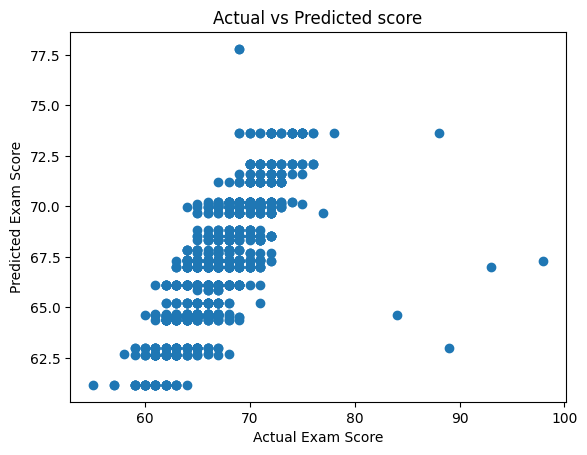

In [52]:
plt.scatter(y_test,y_pred_DTR)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted score")
plt.show()

#### RANDOM FOREST REGRESSOR

In [53]:
#RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor
RFR=RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42)
RFR.fit(X_train,y_train)
y_pred_RFR=RFR.predict(X_test)
print("R2 Score for RFR :",r2_score(y_test,y_pred_RFR))

print("Train Score :",RFR.score(X_train,y_train))
print("Test Score :",RFR.score(X_test,y_test))

R2 Score for RFR : 0.7000822755294548
Train Score : 0.8182606206856978
Test Score : 0.7000822755294548


In [54]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(RFR,X,y,cv=5,scoring='r2')
print("Cross val score :",scores)
print("Avg CV Score :",scores.mean())
print()

Cross val score : [0.53669752 0.61616609 0.60371234 0.63067678 0.70204981]
Avg CV Score : 0.6178605075862594



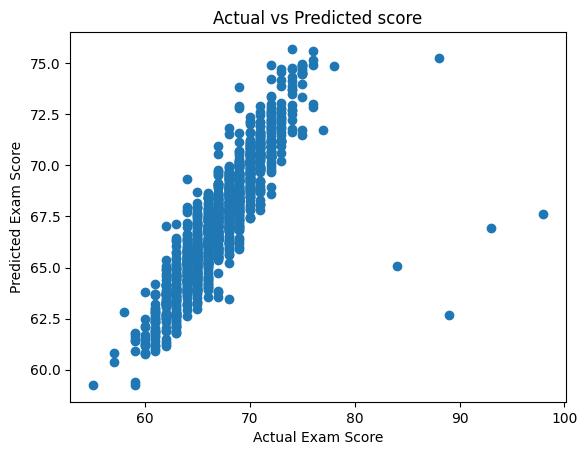

In [55]:
plt.scatter(y_test,y_pred_RFR)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted score")
plt.show()

In [56]:
import pandas as pd

importance = pd.Series(RFR.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

attendance                    0.446323
hours_studied                 0.266072
previous_scores               0.080949
tutoring_sessions             0.029034
access_to_resources_low       0.021325
physical_activity             0.019591
sleep_hours                   0.019325
parental_involvement_low      0.018005
access_to_resources_medium    0.008279
peer_influence_positive       0.007701
dtype: float64

#### GRADIET BOOSTING REGRESSOR

In [57]:
#GRADIET BOOSTING REGRESSOR

from sklearn.ensemble import GradientBoostingRegressor
GBR=GradientBoostingRegressor(random_state=42)
GBR.fit(X_train,y_train)
y_pred_GBR=GBR.predict(X_test)
print("R2 Score for GBR :",r2_score(y_test,y_pred_GBR))

print("Train Score :",GBR.score(X_train,y_train))
print("Test Score :",GBR.score(X_test,y_test))

R2 Score for GBR : 0.777891701232476
Train Score : 0.727476347660664
Test Score : 0.777891701232476


In [58]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(GBR,X,y,cv=5,scoring='r2')
print("Cross val score :",scores)
print("Avg CV Score :",scores.mean())
print()

Cross val score : [0.58662304 0.70069838 0.67889713 0.69646495 0.7889729 ]
Avg CV Score : 0.6903312794401701



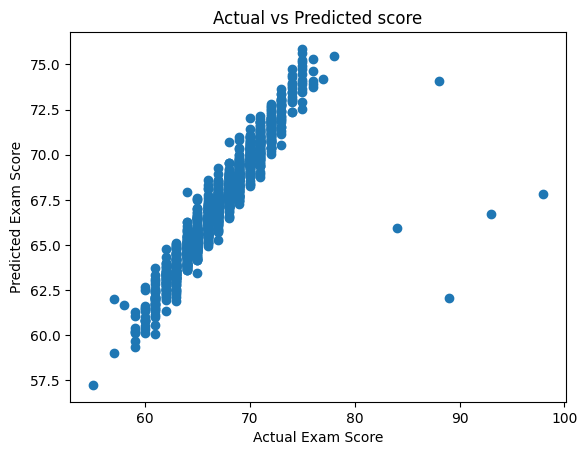

In [59]:
plt.scatter(y_test,y_pred_GBR)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted score")
plt.show()

Multiple regression models were trained and evaluated. Linear Regression achieved the highest R² score of 0.7696, outperforming Decision Tree, Random Forest, and Gradient Boosting. Therefore, Linear Regression was selected as the final model for predicting student exam scores.

In [62]:
results = {
    "Linear Regression": 0.8249,
    "Decision Tree": 0.5694,
    "Random Forest": 0.7000,
    "Gradient Boosting":  0.77789
}

pd.DataFrame(results.items(), columns=["Model","R2 Score"])

,Model,R2 Score
0,Linear Regression,0.82490
1,Decision Tree,0.56940
2,Random Forest,0.70000
3,Gradient Boosting,0.77789


#### Check the correaltion 

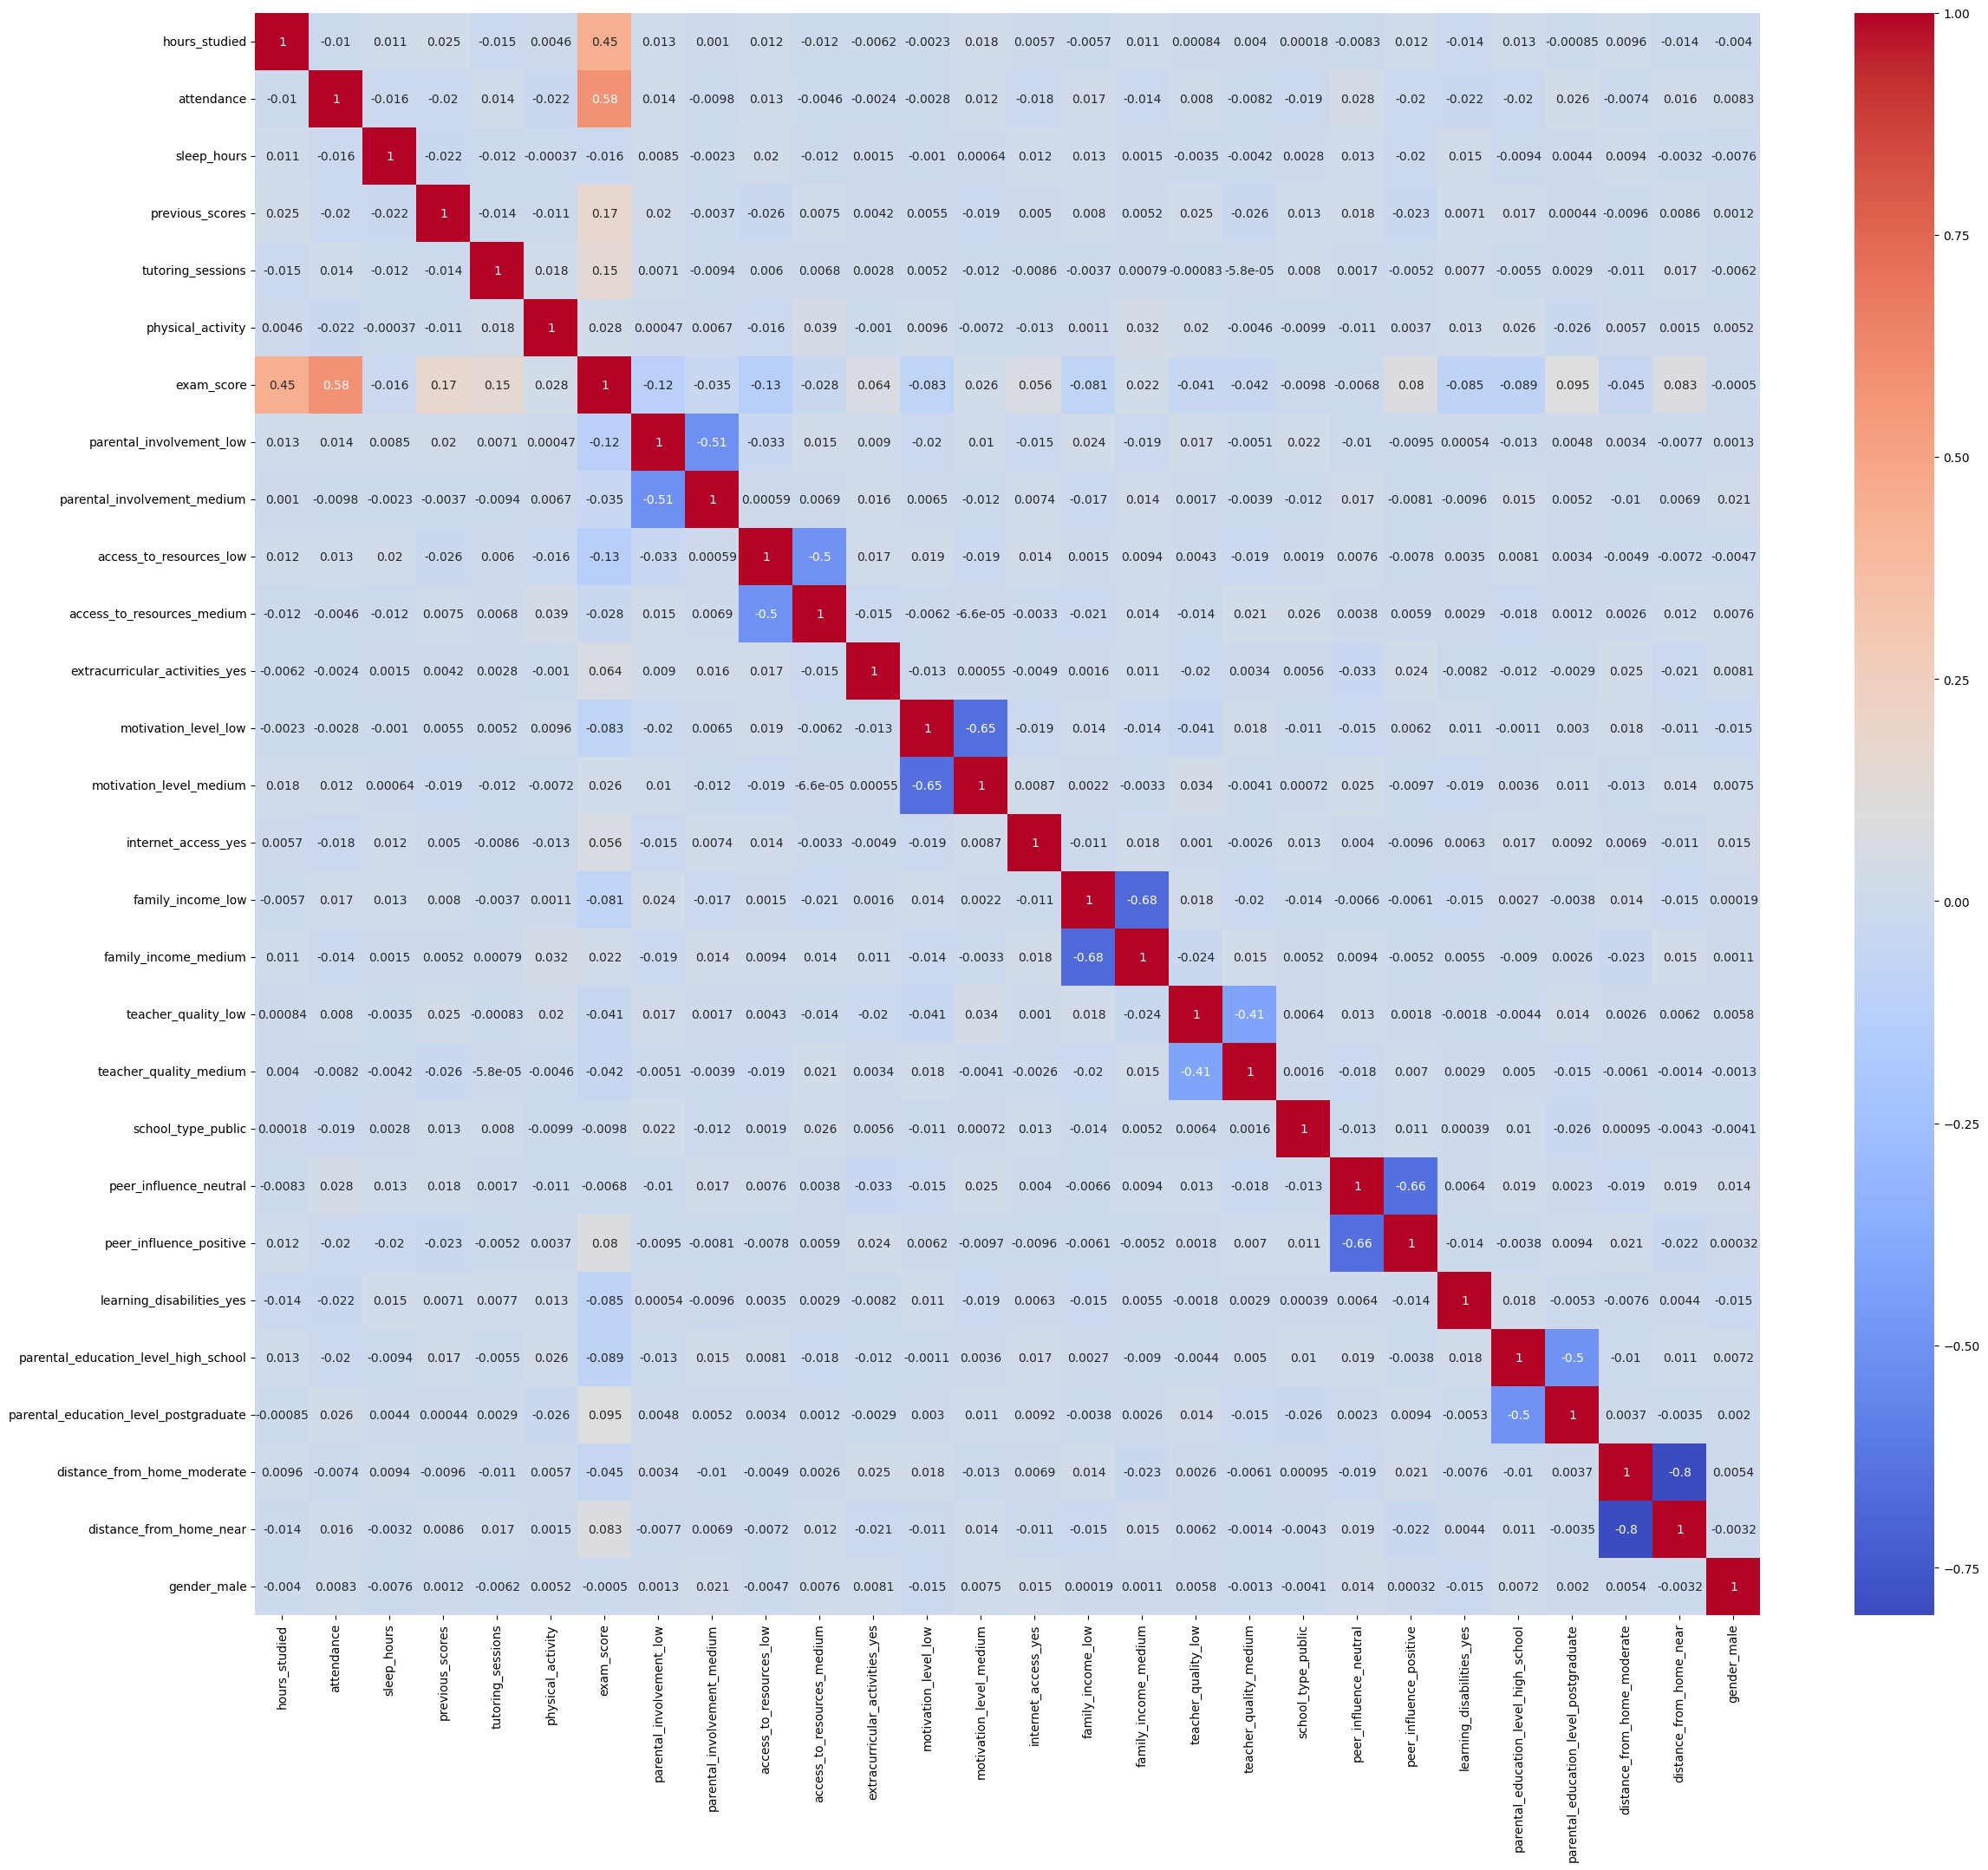

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(28,24))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Save the file 

In [64]:
import pickle

pickle.dump(model,open('student_score_model.pkl','wb'))

In [65]:
for col in X_test.columns:
    print(col)

hours_studied
attendance
sleep_hours
previous_scores
tutoring_sessions
physical_activity
parental_involvement_low
parental_involvement_medium
access_to_resources_low
access_to_resources_medium
extracurricular_activities_yes
motivation_level_low
motivation_level_medium
internet_access_yes
family_income_low
family_income_medium
teacher_quality_low
teacher_quality_medium
school_type_public
peer_influence_neutral
peer_influence_positive
learning_disabilities_yes
parental_education_level_high_school
parental_education_level_postgraduate
distance_from_home_moderate
distance_from_home_near
gender_male


In [66]:
data["exam_score"].describe()

count    6606.000000
mean       67.230548
std         3.868502
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: exam_score, dtype: float64